# Both/Neither + 4-way research scratch (archived)

Lifted out of `02_visualization.ipynb`. This is exploratory work on:
- Skip-bad / skip-nudge query filtering (`gauss_search_skipbad*`, `gauss_search_skipnudge`)
- Both-answer belief update (`both_update`, `gauss_search_v2`, `gauss_search_cheat_v2`)
- 4-way simulated user (`simulated_user_4way*`)
- Rank evolution diagnostics (`target_rank`, `run_rank_diagnostic`)

Superseded by later work (both-similar oracle in notebook 09 scenery, γ-CKL implementation). Kept for reference, not maintained.


In [17]:
import pandas as pd

def gauss_search_diagnostic(X, target_idx, sigma_eps, max_queries, rng, stop_on="in_query"):
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    log = []
    step_stopped = None
    mu_history = [mu.copy()]
    Sigma_history = [Sigma.copy()]
    queries = []
    answers = []

    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                step_stopped = step
                break

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        signed_dist = float(x_t @ w + b)
        prob_i = float(norm.cdf(signed_dist / sigma_eps))
        d_i = float(np.linalg.norm(x_t - x_i))
        d_j = float(np.linalg.norm(x_t - x_j))

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        queries.append((i, j))
        answers.append(y)

        truth = 0 if d_i < d_j else 1
        oracle_flipped = (y != truth)

        sld_before = float(np.linalg.slogdet(Sigma)[1])
        trace_before = float(np.trace(Sigma))

        if stop_on == "in_query" and target_idx in (i, j):
            log.append({
                "step": step, "i": i, "j": j, "y": y,
                "d_i": d_i, "d_j": d_j, "d_min": min(d_i, d_j), "d_max": max(d_i, d_j),
                "signed_dist": signed_dist, "abs_signed_dist": abs(signed_dist),
                "prob_i": prob_i, "truth": truth, "oracle_flipped": oracle_flipped,
                "trace_before": trace_before, "trace_after": np.nan,
                "slogdet_before": sld_before, "slogdet_after": np.nan,
                "info_gain": np.nan, "mu_shift": np.nan, "terminal": True,
            })
            step_stopped = step + 1
            break

        mu_new, Sigma_new = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)
        sld_after = float(np.linalg.slogdet(Sigma_new)[1])
        trace_after = float(np.trace(Sigma_new))
        mu_shift = float(np.linalg.norm(mu_new - mu))
        info_gain = 0.5 * (sld_before - sld_after)

        log.append({
            "step": step, "i": i, "j": j, "y": y,
            "d_i": d_i, "d_j": d_j, "d_min": min(d_i, d_j), "d_max": max(d_i, d_j),
            "signed_dist": signed_dist, "abs_signed_dist": abs(signed_dist),
            "prob_i": prob_i, "truth": truth, "oracle_flipped": oracle_flipped,
            "trace_before": trace_before, "trace_after": trace_after,
            "slogdet_before": sld_before, "slogdet_after": sld_after,
            "info_gain": info_gain, "mu_shift": mu_shift, "terminal": False,
        })

        mu, Sigma = mu_new, Sigma_new
        mu_history.append(mu.copy())
        Sigma_history.append(Sigma.copy())

    return {
        "log": log, "mu_history": mu_history, "Sigma_history": Sigma_history,
        "queries": queries, "answers": answers,
        "step_stopped": step_stopped, "target_idx": target_idx,
    }

print("gauss_search_diagnostic loaded")

gauss_search_diagnostic loaded


In [18]:
rng_solo = np.random.default_rng(seed=1042)
X_solo = make_dataset(n=200, d=2, rng=rng_solo)
target_solo = int(rng_solo.integers(0, 200))
res_solo = gauss_search_diagnostic(X_solo, target_solo, SIGMA_EPS,
                                    max_queries=100, rng=rng_solo, stop_on="in_query")

df_solo = pd.DataFrame(res_solo["log"])
print(f"target: {target_solo} at {X_solo[target_solo].round(3)}")
print(f"steps taken: {res_solo['step_stopped']}\n")

cols = ["step", "d_min", "d_max", "abs_signed_dist", "prob_i",
        "y", "truth", "oracle_flipped", "info_gain", "mu_shift", "terminal"]
print(df_solo[cols].round(3).to_string(index=False))

target: 48 at [-0.431 -0.547]
steps taken: 9

 step  d_min  d_max  abs_signed_dist  prob_i  y  truth  oracle_flipped  info_gain  mu_shift  terminal
    0  1.292  1.796            0.652   0.999  0      0           False      0.455     0.741     False
    1  0.544  1.397            0.439   0.986  0      0           False      0.461     0.752     False
    2  0.674  0.749            0.042   0.583  0      0           False      0.322     0.321     False
    3  0.442  0.560            0.328   0.051  1      1           False      0.480     0.554     False
    4  0.426  0.454            0.161   0.210  0      1            True      0.358     0.286     False
    5  0.334  0.488            0.332   0.952  0      0           False      0.363     0.353     False
    6  0.460  0.533            0.036   0.572  1      0            True      0.447     0.441     False
    7  0.282  0.620            0.169   0.801  0      0           False      0.266     0.172     False
    8  0.000  0.193            0.096

total non-terminal queries across 100 searches: 921
mean info gain per query: 0.3316
fraction of queries with info_gain < 0.01: 0.0%
fraction where oracle flipped: 19.1%


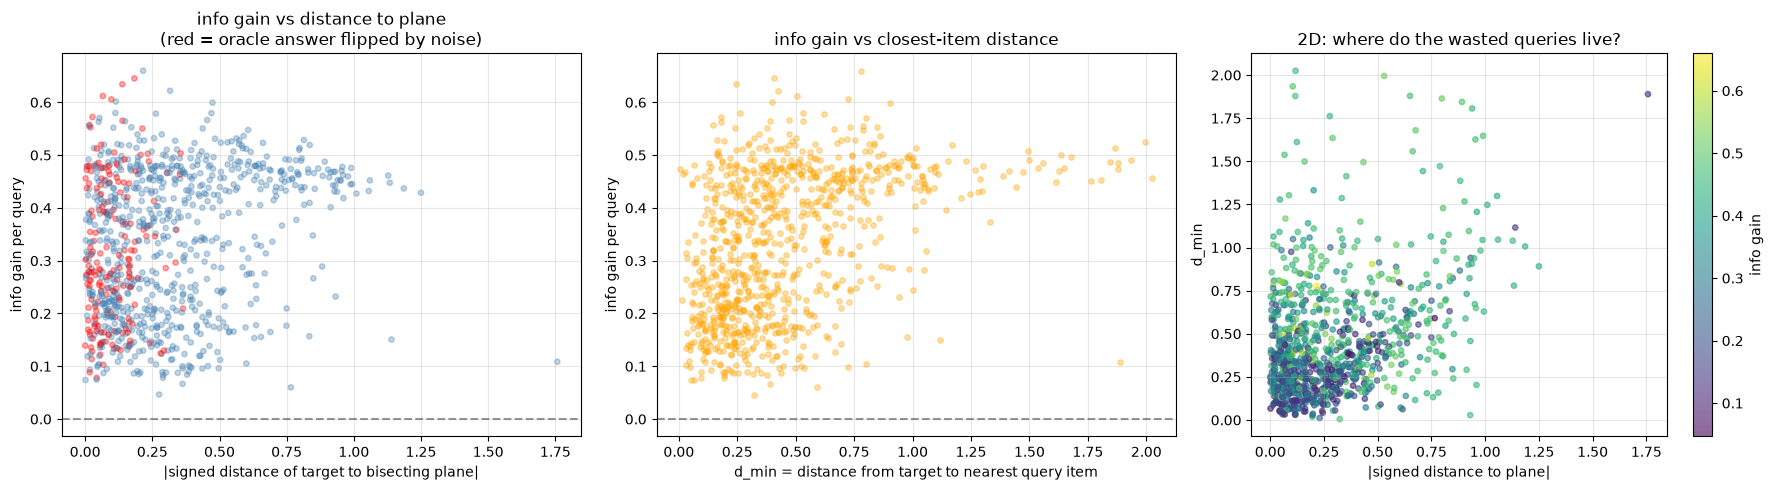

In [19]:
all_logs = []
for trial in range(100):
    rng_trial = np.random.default_rng(seed=2000 + trial)
    X_trial = make_dataset(n=200, d=2, rng=rng_trial)
    tgt = int(rng_trial.integers(0, 200))
    res = gauss_search_diagnostic(X_trial, tgt, SIGMA_EPS,
                                   max_queries=100, rng=rng_trial, stop_on="in_query")
    for row in res["log"]:
        if not row["terminal"]:
            row["trial"] = trial
            all_logs.append(row)

df_all = pd.DataFrame(all_logs)
print(f"total non-terminal queries across 100 searches: {len(df_all)}")
print(f"mean info gain per query: {df_all['info_gain'].mean():.4f}")
print(f"fraction of queries with info_gain < 0.01: {(df_all['info_gain'] < 0.01).mean()*100:.1f}%")
print(f"fraction where oracle flipped: {df_all['oracle_flipped'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(df_all["abs_signed_dist"], df_all["info_gain"],
           c=df_all["oracle_flipped"].map({True: "red", False: "steelblue"}),
           alpha=0.35, s=15)
ax.axhline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel("|signed distance of target to bisecting plane|")
ax.set_ylabel("info gain per query")
ax.set_title("info gain vs distance to plane\n(red = oracle answer flipped by noise)")
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(df_all["d_min"], df_all["info_gain"], alpha=0.35, s=15, c="orange")
ax.axhline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel("d_min = distance from target to nearest query item")
ax.set_ylabel("info gain per query")
ax.set_title("info gain vs closest-item distance")
ax.grid(alpha=0.3)

ax = axes[2]
sc = ax.scatter(df_all["abs_signed_dist"], df_all["d_min"],
                c=df_all["info_gain"], cmap="viridis", alpha=0.6, s=15)
plt.colorbar(sc, ax=ax, label="info gain")
ax.set_xlabel("|signed distance to plane|")
ax.set_ylabel("d_min")
ax.set_title("2D: where do the wasted queries live?")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
sd_thr = df_all["abs_signed_dist"].quantile(0.30)
dmin_thr = df_all["d_min"].quantile(0.70)
print(f"thresholds used:")
print(f"  near-plane if |signed_dist| < {sd_thr:.3f}  (bottom 30% of queries)")
print(f"  far-from-items if d_min > {dmin_thr:.3f}    (top 30% of queries)")
print()

def classify(row):
    near = row["abs_signed_dist"] < sd_thr
    far = row["d_min"] > dmin_thr
    if near and far:  return "NEITHER-like"
    if near and not far: return "BOTH-like"
    if not near and far: return "weak A/B"
    return "decisive A/B"

df_all["category"] = df_all.apply(classify, axis=1)

summary = df_all.groupby("category").agg(
    count=("info_gain", "size"),
    mean_info_gain=("info_gain", "mean"),
    median_info_gain=("info_gain", "median"),
    flip_rate=("oracle_flipped", "mean"),
).round(4)
summary["pct_of_queries"] = (summary["count"] / summary["count"].sum() * 100).round(1)
summary = summary.sort_values("mean_info_gain", ascending=False)
print("per-category breakdown:")
print(summary)
print()

decisive_gain = summary.loc["decisive A/B", "mean_info_gain"] if "decisive A/B" in summary.index else 0
for cat in ["BOTH-like", "NEITHER-like", "weak A/B"]:
    if cat in summary.index:
        g = summary.loc[cat, "mean_info_gain"]
        pct = summary.loc[cat, "pct_of_queries"]
        deficit = (decisive_gain - g) / decisive_gain * 100 if decisive_gain > 0 else 0
        print(f"  {cat}: {pct:.1f}% of queries, {deficit:.0f}% less info than decisive queries")

thresholds used:
  near-plane if |signed_dist| < 0.115  (bottom 30% of queries)
  far-from-items if d_min > 0.545    (top 30% of queries)

per-category breakdown:
              count  mean_info_gain  median_info_gain  flip_rate  \
category                                                           
weak A/B        216          0.4134            0.4491     0.0972   
NEITHER-like     60          0.4001            0.4370     0.4333   
decisive A/B    429          0.3062            0.2922     0.1072   
BOTH-like       216          0.2814            0.2564     0.3843   

              pct_of_queries  
category                      
weak A/B                23.5  
NEITHER-like             6.5  
decisive A/B            46.6  
BOTH-like               23.5  

  BOTH-like: 23.5% of queries, 8% less info than decisive queries
  NEITHER-like: 6.5% of queries, -31% less info than decisive queries
  weak A/B: 23.5% of queries, -35% less info than decisive queries


In [21]:
progress_data = []
for row in all_logs:
    if row["terminal"]:
        continue
    trial = row["trial"]
    step = row["step"]
    rng_r = np.random.default_rng(seed=2000 + trial)
    X_r = make_dataset(n=200, d=2, rng=rng_r)
    tgt_r = int(rng_r.integers(0, 200))
    x_t = X_r[tgt_r]

df_all["dist_before"] = np.nan
df_all["dist_after"] = np.nan
df_all["progress"] = np.nan

for trial in df_all["trial"].unique():
    rng_r = np.random.default_rng(seed=2000 + trial)
    X_r = make_dataset(n=200, d=2, rng=rng_r)
    tgt_r = int(rng_r.integers(0, 200))
    res_r = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=100, rng=rng_r, stop_on="in_query")
    x_t = X_r[tgt_r]
    for k, row in enumerate(res_r["log"]):
        if row["terminal"]:
            continue
        mu_before = res_r["mu_history"][k]
        mu_after = res_r["mu_history"][k + 1] if (k + 1) < len(res_r["mu_history"]) else mu_before
        dist_before = np.linalg.norm(mu_before - x_t)
        dist_after = np.linalg.norm(mu_after - x_t)
        mask = (df_all["trial"] == trial) & (df_all["step"] == row["step"])
        df_all.loc[mask, "dist_before"] = dist_before
        df_all.loc[mask, "dist_after"] = dist_after
        df_all.loc[mask, "progress"] = dist_before - dist_after

progress_summary = df_all.groupby("category").agg(
    count=("progress", "size"),
    mean_progress=("progress", "mean"),
    median_progress=("progress", "median"),
    frac_negative=("progress", lambda x: (x < 0).mean()),
    mean_info_gain=("info_gain", "mean"),
    flip_rate=("oracle_flipped", "mean"),
).round(4)
progress_summary["pct"] = (progress_summary["count"] / progress_summary["count"].sum() * 100).round(1)
print("progress toward target, per category:")
print(progress_summary)
print()
print("interpretation:")
print("  mean_progress > 0: category updates on average pull µ toward target")
print("  mean_progress < 0: category updates on average push µ away from target")
print("  frac_negative:     fraction of updates in this category that hurt")

progress toward target, per category:
              count  mean_progress  median_progress  frac_negative  \
category                                                             
BOTH-like       216        -0.0545          -0.0462         0.7315   
NEITHER-like     60        -0.1907          -0.1505         0.7667   
decisive A/B    429         0.1009           0.0824         0.2494   
weak A/B        216         0.1314           0.1277         0.3519   

              mean_info_gain  flip_rate   pct  
category                                       
BOTH-like             0.2814     0.3843  23.5  
NEITHER-like          0.4001     0.4333   6.5  
decisive A/B          0.3062     0.1072  46.6  
weak A/B              0.4134     0.0972  23.5  

interpretation:
  mean_progress > 0: category updates on average pull µ toward target
  mean_progress < 0: category updates on average push µ away from target
  frac_negative:     fraction of updates in this category that hurt


In [22]:
trial_lengths = []
for trial in df_all["trial"].unique():
    rng_r = np.random.default_rng(seed=2000 + trial)
    X_r = make_dataset(n=200, d=2, rng=rng_r)
    tgt_r = int(rng_r.integers(0, 200))
    res_r = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=100, rng=rng_r, stop_on="in_query")
    trial_lengths.append(res_r["step_stopped"])

trial_lengths = np.array(trial_lengths)
print(f"BASELINE (n=200, d=2, in-query stop, 100 trials):")
print(f"  mean queries:    {trial_lengths.mean():.2f}")
print(f"  median queries:  {np.median(trial_lengths):.1f}")
print(f"  min / max:       {trial_lengths.min()} / {trial_lengths.max()}")
print(f"  p95:             {np.percentile(trial_lengths, 95):.1f}")
print(f"  total queries:   {trial_lengths.sum()}")
print()

print("aggregate damage per category (count × mean_progress):")
for cat in ["decisive A/B", "weak A/B", "BOTH-like", "NEITHER-like"]:
    sub = df_all[df_all["category"] == cat]
    total = (sub["progress"].sum())
    print(f"  {cat:15s}: count={len(sub):3d}, "
          f"mean_progress={sub['progress'].mean():+.4f}, "
          f"total_progress={total:+.3f}")

total_progress_all = df_all["progress"].sum()
harmful = df_all[df_all["progress"] < 0]["progress"].sum()
helpful = df_all[df_all["progress"] > 0]["progress"].sum()
print()
print(f"across all 921 queries:")
print(f"  total helpful progress: {helpful:+.2f}")
print(f"  total harmful progress: {harmful:+.2f}")
print(f"  net progress:           {total_progress_all:+.2f}")
print(f"  harm as % of help:      {abs(harmful)/helpful*100:.1f}%")

BASELINE (n=200, d=2, in-query stop, 100 trials):
  mean queries:    10.21
  median queries:  10.0
  min / max:       2 / 20
  p95:             17.0
  total queries:   1021

aggregate damage per category (count × mean_progress):
  decisive A/B   : count=429, mean_progress=+0.1009, total_progress=+43.267
  weak A/B       : count=216, mean_progress=+0.1314, total_progress=+28.382
  BOTH-like      : count=216, mean_progress=-0.0545, total_progress=-11.774
  NEITHER-like   : count= 60, mean_progress=-0.1907, total_progress=-11.444

across all 921 queries:
  total helpful progress: +107.42
  total harmful progress: -58.99
  net progress:           +48.43
  harm as % of help:      54.9%


In [23]:
def gauss_search_skipbad(X, target_idx, sigma_eps, max_queries, rng,
                          stop_on="in_query", sd_thresh=None, dmin_thresh=None):
    """GAUSSSEARCH but skip the ADF update if the query looks BOTH-like or NEITHER-like."""
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    skipped = 0
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "skipped": skipped}

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        signed_dist = abs(float(x_t @ w + b))
        d_min = min(float(np.linalg.norm(x_t - x_i)),
                    float(np.linalg.norm(x_t - x_j)))

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)

        if stop_on == "in_query" and target_idx in (i, j):
            return {"n_queries": step + 1, "skipped": skipped}

        near_plane = signed_dist < sd_thresh
        far_items = d_min > dmin_thresh
        if near_plane:
            skipped += 1
        else:
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

    return {"n_queries": max_queries, "skipped": skipped}

print("gauss_search_skipbad loaded")

gauss_search_skipbad loaded


In [24]:
sd_thresh = 0.115
dmin_thresh = 0.545

baseline_lengths = []
skipbad_lengths = []
skipped_counts = []

for trial in range(100):
    rng_r = np.random.default_rng(seed=2000 + trial)
    X_r = make_dataset(n=200, d=2, rng=rng_r)
    tgt_r = int(rng_r.integers(0, 200))

    rng_baseline = np.random.default_rng(seed=2000 + trial + 500000)
    res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=100, rng=rng_baseline, stop_on="in_query")
    baseline_lengths.append(res_b["step_stopped"])

    rng_skip = np.random.default_rng(seed=2000 + trial + 500000)
    res_s = gauss_search_skipbad(X_r, tgt_r, SIGMA_EPS,
                                  max_queries=100, rng=rng_skip, stop_on="in_query",
                                  sd_thresh=sd_thresh, dmin_thresh=dmin_thresh)
    skipbad_lengths.append(res_s["n_queries"])
    skipped_counts.append(res_s["skipped"])

baseline_lengths = np.array(baseline_lengths)
skipbad_lengths = np.array(skipbad_lengths)
skipped_counts = np.array(skipped_counts)

print(f"BASELINE:")
print(f"  mean queries:    {baseline_lengths.mean():.2f}")
print(f"  median:          {np.median(baseline_lengths):.1f}")
print(f"  p95:             {np.percentile(baseline_lengths, 95):.1f}")
print()
print(f"SKIP-BAD-UPDATES (skip when |signed_dist| < {sd_thresh}):")
print(f"  mean queries:    {skipbad_lengths.mean():.2f}")
print(f"  median:          {np.median(skipbad_lengths):.1f}")
print(f"  p95:             {np.percentile(skipbad_lengths, 95):.1f}")
print(f"  mean skipped:    {skipped_counts.mean():.2f} updates per search")
print()
delta = baseline_lengths.mean() - skipbad_lengths.mean()
pct = delta / baseline_lengths.mean() * 100
print(f"CHANGE: {delta:+.2f} queries ({pct:+.1f}%)")
print()
wins = (skipbad_lengths < baseline_lengths).sum()
losses = (skipbad_lengths > baseline_lengths).sum()
ties = (skipbad_lengths == baseline_lengths).sum()
print(f"per-trial: {wins} wins, {losses} losses, {ties} ties (out of 100)")

BASELINE:
  mean queries:    10.21
  median:          10.0
  p95:             16.0

SKIP-BAD-UPDATES (skip when |signed_dist| < 0.115):
  mean queries:    11.92
  median:          11.0
  p95:             23.1
  mean skipped:    3.83 updates per search

CHANGE: -1.71 queries (-16.7%)

per-trial: 25 wins, 47 losses, 28 ties (out of 100)


In [25]:
def gauss_search_skipbad_logged(X, target_idx, sigma_eps, max_queries, rng,
                                  stop_on="in_query", sd_thresh=0.115):
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    log = []
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "log": log}

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        signed_dist = abs(float(x_t @ w + b))

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)

        if stop_on == "in_query" and target_idx in (i, j):
            log.append({"step": step, "i": i, "j": j, "x_i": x_i.copy(), "x_j": x_j.copy(),
                        "skipped": False, "abs_sd": signed_dist, "terminal": True})
            return {"n_queries": step + 1, "log": log}

        near_plane = signed_dist < sd_thresh
        log.append({"step": step, "i": i, "j": j, "x_i": x_i.copy(), "x_j": x_j.copy(),
                    "skipped": near_plane, "abs_sd": signed_dist, "terminal": False})

        if not near_plane:
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

    return {"n_queries": max_queries, "log": log}


# find a trial where skip lost badly
losing_trials = []
for trial in range(100):
    rng_r = np.random.default_rng(seed=2000 + trial)
    X_r = make_dataset(n=200, d=2, rng=rng_r)
    tgt_r = int(rng_r.integers(0, 200))
    rng_skip = np.random.default_rng(seed=2000 + trial + 500000)
    res_s = gauss_search_skipbad_logged(X_r, tgt_r, SIGMA_EPS,
                                         max_queries=100, rng=rng_skip, stop_on="in_query")
    n_skipped = sum(1 for r in res_s["log"] if r.get("skipped"))
    losing_trials.append((res_s["n_queries"], n_skipped, trial, res_s["log"], X_r, tgt_r))

losing_trials.sort(key=lambda x: -x[0])  # longest first
n_q, n_skip, trial, log, X_r, tgt_r = losing_trials[0]
print(f"worst trial: #{trial}, took {n_q} queries, {n_skip} skips")
print()
print(f"  step  i    j    abs_sd   skipped")
for row in log:
    marker = " SKIP" if row["skipped"] else ""
    marker += " TERM" if row.get("terminal") else ""
    print(f"  {row['step']:>3}  {row['i']:>3}  {row['j']:>3}  {row['abs_sd']:>7.3f}  {marker}")

print()
skip_pairs = [(r["i"], r["j"]) for r in log if r["skipped"]]
if len(skip_pairs) >= 2:
    print("distance between consecutive skipped query pair midpoints:")
    prev = None
    for row in log:
        if row["skipped"]:
            mid = 0.5 * (row["x_i"] + row["x_j"])
            if prev is not None:
                print(f"  step {row['step']:>3}: |midpoint − prev midpoint| = {np.linalg.norm(mid - prev):.4f}")
            prev = mid

worst trial: #7, took 33 queries, 23 skips

  step  i    j    abs_sd   skipped
    0   91  136    0.076   SKIP
    1   75  151    0.005   SKIP
    2    9  161    0.096   SKIP
    3  180   76    0.130  
    4  193   89    0.426  
    5   78   66    0.452  
    6  133  198    0.507  
    7    8  135    0.416  
    8  183   26    0.054   SKIP
    9  105   71    0.106   SKIP
   10  164   52    0.019   SKIP
   11   81  181    0.043   SKIP
   12  103   94    0.043   SKIP
   13  110   57    0.006   SKIP
   14   88  176    0.010   SKIP
   15    3  140    0.007   SKIP
   16   95   63    0.065   SKIP
   17   30   62    0.166  
   18   18  177    0.515  
   19    0  158    0.139  
   20  157  172    0.053   SKIP
   21  190  102    0.106   SKIP
   22   40  174    0.043   SKIP
   23   59   51    0.030   SKIP
   24  179  109    0.293  
   25  131    7    0.026   SKIP
   26  124   31    0.030   SKIP
   27   79  141    0.015   SKIP
   28  147  121    0.050   SKIP
   29   11  156    0.038   SKIP
   30 

In [26]:
def gauss_search_skipnudge(X, target_idx, sigma_eps, max_queries, rng,
                            stop_on="in_query", sd_thresh=0.115, shrink_factor=0.5):
    """Skip the ADF mean update on BOTH-like queries, but shrink Sigma along w.

    This tests whether the axis-rotation effect of the update was doing the work.
    """
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    skipped = 0
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "skipped": skipped}

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        signed_dist = abs(float(x_t @ w + b))

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)

        if stop_on == "in_query" and target_idx in (i, j):
            return {"n_queries": step + 1, "skipped": skipped}

        near_plane = signed_dist < sd_thresh
        if near_plane:
            skipped += 1
            # nudge Sigma: shrink variance along w by shrink_factor, leave mu alone.
            # Sigma_new = Sigma - shrink * (Sigma w)(Sigma w)^T / (w^T Sigma w)
            Sw = Sigma @ w
            wSw = float(w @ Sw)
            if wSw > 1e-12:
                Sigma = Sigma - shrink_factor * np.outer(Sw, Sw) / wSw
                Sigma = symmetrize(Sigma)
        else:
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

    return {"n_queries": max_queries, "skipped": skipped}


baseline_lengths = []
skipbad_lengths = []
nudge_lengths = []
nudge_skipped = []

for trial in range(100):
    rng_r = np.random.default_rng(seed=2000 + trial)
    X_r = make_dataset(n=200, d=2, rng=rng_r)
    tgt_r = int(rng_r.integers(0, 200))

    rng_baseline = np.random.default_rng(seed=2000 + trial + 500000)
    res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=100, rng=rng_baseline, stop_on="in_query")
    baseline_lengths.append(res_b["step_stopped"])

    rng_skip = np.random.default_rng(seed=2000 + trial + 500000)
    res_s = gauss_search_skipbad(X_r, tgt_r, SIGMA_EPS,
                                  max_queries=100, rng=rng_skip, stop_on="in_query",
                                  sd_thresh=0.115, dmin_thresh=0.545)
    skipbad_lengths.append(res_s["n_queries"])

    rng_nudge = np.random.default_rng(seed=2000 + trial + 500000)
    res_n = gauss_search_skipnudge(X_r, tgt_r, SIGMA_EPS,
                                    max_queries=100, rng=rng_nudge, stop_on="in_query",
                                    sd_thresh=0.115, shrink_factor=0.5)
    nudge_lengths.append(res_n["n_queries"])
    nudge_skipped.append(res_n["skipped"])

baseline_lengths = np.array(baseline_lengths)
skipbad_lengths = np.array(skipbad_lengths)
nudge_lengths = np.array(nudge_lengths)

print(f"{'variant':<25} {'mean':>6} {'median':>7} {'p95':>5}")
print(f"{'-'*45}")
print(f"{'baseline':<25} {baseline_lengths.mean():>6.2f} {np.median(baseline_lengths):>7.1f} {np.percentile(baseline_lengths, 95):>5.1f}")
print(f"{'skip-bad':<25} {skipbad_lengths.mean():>6.2f} {np.median(skipbad_lengths):>7.1f} {np.percentile(skipbad_lengths, 95):>5.1f}")
print(f"{'skip + nudge Sigma':<25} {nudge_lengths.mean():>6.2f} {np.median(nudge_lengths):>7.1f} {np.percentile(nudge_lengths, 95):>5.1f}")
print()
print(f"nudge vs baseline: {nudge_lengths.mean() - baseline_lengths.mean():+.2f} queries")
print(f"nudge wins/losses/ties vs baseline: "
      f"{(nudge_lengths < baseline_lengths).sum()} / "
      f"{(nudge_lengths > baseline_lengths).sum()} / "
      f"{(nudge_lengths == baseline_lengths).sum()}")

variant                     mean  median   p95
---------------------------------------------
baseline                   10.21    10.0  16.0
skip-bad                   11.92    11.0  23.1
skip + nudge Sigma          9.92    10.0  15.0

nudge vs baseline: -0.29 queries
nudge wins/losses/ties vs baseline: 38 / 34 / 28


In [28]:
def make_dataset_d(n, d, rng):
    return rng.uniform(-1, 1, size=(n, d))

N_DIAG = 500
D_DIAG = 5
N_TRIALS_DIAG = 100

print(f"running diagnostic at n={N_DIAG}, d={D_DIAG}, {N_TRIALS_DIAG} trials, in-query stop\n")

all_logs_hd = []
trial_lengths_hd = []
for trial in range(N_TRIALS_DIAG):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(N_DIAG, D_DIAG, rng_r)
    tgt_r = int(rng_r.integers(0, N_DIAG))
    res = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                   max_queries=200, rng=rng_r, stop_on="in_query")
    trial_lengths_hd.append(res["step_stopped"])
    for k, row in enumerate(res["log"]):
        if row["terminal"]:
            continue
        mu_before = res["mu_history"][k]
        mu_after = res["mu_history"][k + 1] if (k + 1) < len(res["mu_history"]) else mu_before
        x_t = X_r[tgt_r]
        row["dist_before"] = float(np.linalg.norm(mu_before - x_t))
        row["dist_after"] = float(np.linalg.norm(mu_after - x_t))
        row["progress"] = row["dist_before"] - row["dist_after"]
        row["trial"] = trial
        all_logs_hd.append(row)

trial_lengths_hd = np.array(trial_lengths_hd)
df_hd = pd.DataFrame(all_logs_hd)

print(f"BASELINE at n={N_DIAG}, d={D_DIAG}:")
print(f"  mean queries:  {trial_lengths_hd.mean():.2f}")
print(f"  median:        {np.median(trial_lengths_hd):.1f}")
print(f"  p95:           {np.percentile(trial_lengths_hd, 95):.1f}")
print(f"  total non-terminal queries logged: {len(df_hd)}")
print()

sd_thr_hd = df_hd["abs_signed_dist"].quantile(0.30)
dmin_thr_hd = df_hd["d_min"].quantile(0.70)
print(f"thresholds: |signed_dist| < {sd_thr_hd:.3f} (near-plane), d_min > {dmin_thr_hd:.3f} (far-items)\n")

def classify_hd(row):
    near = row["abs_signed_dist"] < sd_thr_hd
    far = row["d_min"] > dmin_thr_hd
    if near and far:  return "NEITHER-like"
    if near and not far: return "BOTH-like"
    if not near and far: return "weak A/B"
    return "decisive A/B"

df_hd["category"] = df_hd.apply(classify_hd, axis=1)

summary_hd = df_hd.groupby("category").agg(
    count=("progress", "size"),
    mean_progress=("progress", "mean"),
    frac_negative=("progress", lambda x: (x < 0).mean()),
    mean_info_gain=("info_gain", "mean"),
    flip_rate=("oracle_flipped", "mean"),
).round(4)
summary_hd["pct"] = (summary_hd["count"] / summary_hd["count"].sum() * 100).round(1)
summary_hd["total_progress"] = (summary_hd["count"] * summary_hd["mean_progress"]).round(2)
print("per-category breakdown:")
print(summary_hd)
print()

helpful_hd = df_hd[df_hd["progress"] > 0]["progress"].sum()
harmful_hd = df_hd[df_hd["progress"] < 0]["progress"].sum()
print(f"aggregate: helpful={helpful_hd:+.1f}, harmful={harmful_hd:+.1f}, "
      f"harm as % of help: {abs(harmful_hd)/helpful_hd*100:.1f}%")

running diagnostic at n=500, d=5, 100 trials, in-query stop

BASELINE at n=500, d=5:
  mean queries:  11.74
  median:        11.0
  p95:           20.0
  total non-terminal queries logged: 1074

thresholds: |signed_dist| < 0.243 (near-plane), d_min > 1.354 (far-items)

per-category breakdown:
              count  mean_progress  frac_negative  mean_info_gain  flip_rate  \
category                                                                       
BOTH-like       229        -0.0601         0.7205          0.3912     0.2882   
NEITHER-like     93        -0.1424         0.8817          0.4567     0.2043   
decisive A/B    523         0.1005         0.2964          0.3652     0.0421   
weak A/B        229         0.1085         0.2969          0.4106     0.0262   

               pct  total_progress  
category                            
BOTH-like     21.3          -13.76  
NEITHER-like   8.7          -13.24  
decisive A/B  48.7           52.56  
weak A/B      21.3           24.85  

ag

In [29]:
baseline_hd = []
cheat_hd = []
nudge_hd = []

for trial in range(N_TRIALS_DIAG):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(N_DIAG, D_DIAG, rng_r)
    tgt_r = int(rng_r.integers(0, N_DIAG))

    rng_baseline = np.random.default_rng(seed=3000 + trial + 500000)
    res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=200, rng=rng_baseline, stop_on="in_query")
    baseline_hd.append(res_b["step_stopped"])

    rng_nudge = np.random.default_rng(seed=3000 + trial + 500000)
    res_n = gauss_search_skipnudge(X_r, tgt_r, SIGMA_EPS,
                                    max_queries=200, rng=rng_nudge, stop_on="in_query",
                                    sd_thresh=sd_thr_hd, shrink_factor=0.5)
    nudge_hd.append(res_n["n_queries"])

    rng_cheat = np.random.default_rng(seed=3000 + trial + 500000)
    res_c = gauss_search_cheat(X_r, tgt_r, SIGMA_EPS,
                                max_queries=200, rng=rng_cheat, stop_on="in_query",
                                sd_thresh=sd_thr_hd, shrink_factor=0.5)
    cheat_hd.append(res_c["n_queries"])

baseline_hd = np.array(baseline_hd)
nudge_hd = np.array(nudge_hd)
cheat_hd = np.array(cheat_hd)

print(f"n={N_DIAG}, d={D_DIAG}, in-query stop:\n")
print(f"{'variant':<25} {'mean':>6} {'median':>7} {'p95':>5}")
print(f"{'-'*45}")
print(f"{'baseline':<25} {baseline_hd.mean():>6.2f} {np.median(baseline_hd):>7.1f} {np.percentile(baseline_hd, 95):>5.1f}")
print(f"{'skip + nudge Sigma':<25} {nudge_hd.mean():>6.2f} {np.median(nudge_hd):>7.1f} {np.percentile(nudge_hd, 95):>5.1f}")
print(f"{'CHEAT (mu -> plane)':<25} {cheat_hd.mean():>6.2f} {np.median(cheat_hd):>7.1f} {np.percentile(cheat_hd, 95):>5.1f}")
print()
print(f"nudge vs baseline: {nudge_hd.mean() - baseline_hd.mean():+.2f} queries "
      f"({(nudge_hd.mean() - baseline_hd.mean())/baseline_hd.mean()*100:+.1f}%)")
print(f"cheat vs baseline: {cheat_hd.mean() - baseline_hd.mean():+.2f} queries "
      f"({(cheat_hd.mean() - baseline_hd.mean())/baseline_hd.mean()*100:+.1f}%)")

n=500, d=5, in-query stop:

variant                     mean  median   p95
---------------------------------------------
baseline                   11.99    11.0  20.0
skip + nudge Sigma         12.17    12.0  19.0
CHEAT (mu -> plane)        11.53    11.0  19.0

nudge vs baseline: +0.18 queries (+1.5%)
cheat vs baseline: -0.46 queries (-3.8%)


In [30]:
def gauss_search_cheat_v2(X, target_idx, sigma_eps, max_queries, rng,
                           stop_on="in_query", sd_thresh=0.243,
                           midpoint_thresh_frac=1.0, shrink_plane=0.5, shrink_mid=0.5):
    """CHEAT v2: on 'both-like' queries, use BOTH pieces of info:
       (1) target is near the bisecting plane  -> pull mu toward plane, shrink Sigma along w
       (2) target is near the midpoint m       -> pull mu toward m, shrink Sigma along (mu - m)
       
       'both-like' = near-plane AND target actually close to both items.
       midpoint_thresh_frac controls the ball radius as a fraction of ||x_i - x_j|| / 2.
    """
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    handled = 0
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "handled": handled}

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        m = 0.5 * (x_i + x_j)
        half_sep = 0.5 * float(np.linalg.norm(x_i - x_j))
        r_thresh = midpoint_thresh_frac * half_sep

        signed_dist_target = float(x_t @ w + b)
        dist_to_mid = float(np.linalg.norm(x_t - m))

        near_plane = abs(signed_dist_target) < sd_thresh
        near_mid = dist_to_mid < r_thresh

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)

        if stop_on == "in_query" and target_idx in (i, j):
            return {"n_queries": step + 1, "handled": handled}

        if near_plane and near_mid:
            handled += 1
            # STEP 1: pull mu to the plane (target's signed-dist ≈ 0 means w·x_t ≈ -b)
            mu_signed = float(w @ mu + b)
            mu = mu - mu_signed * w
            # shrink Sigma along w
            Sw = Sigma @ w
            wSw = float(w @ Sw)
            if wSw > 1e-12:
                Sigma = Sigma - shrink_plane * np.outer(Sw, Sw) / wSw
                Sigma = symmetrize(Sigma)
            # STEP 2: pull mu toward midpoint m
            direction = m - mu
            dir_norm = float(np.linalg.norm(direction))
            if dir_norm > 1e-12:
                u = direction / dir_norm
                # move mu a fraction of the way to m
                mu = mu + 0.5 * direction   # halfway pull
                # shrink Sigma along u
                Su = Sigma @ u
                uSu = float(u @ Su)
                if uSu > 1e-12:
                    Sigma = Sigma - shrink_mid * np.outer(Su, Su) / uSu
                    Sigma = symmetrize(Sigma)
        else:
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

    return {"n_queries": max_queries, "handled": handled}


baseline_hd2 = []
cheat_hd2 = []
cheat_v2_hd = []
handled_counts = []

for trial in range(N_TRIALS_DIAG):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(N_DIAG, D_DIAG, rng_r)
    tgt_r = int(rng_r.integers(0, N_DIAG))

    rng_b = np.random.default_rng(seed=3000 + trial + 500000)
    res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=200, rng=rng_b, stop_on="in_query")
    baseline_hd2.append(res_b["step_stopped"])

    rng_c1 = np.random.default_rng(seed=3000 + trial + 500000)
    res_c1 = gauss_search_cheat(X_r, tgt_r, SIGMA_EPS,
                                 max_queries=200, rng=rng_c1, stop_on="in_query",
                                 sd_thresh=sd_thr_hd, shrink_factor=0.5)
    cheat_hd2.append(res_c1["n_queries"])

    rng_c2 = np.random.default_rng(seed=3000 + trial + 500000)
    res_c2 = gauss_search_cheat_v2(X_r, tgt_r, SIGMA_EPS,
                                    max_queries=200, rng=rng_c2, stop_on="in_query",
                                    sd_thresh=sd_thr_hd,
                                    midpoint_thresh_frac=1.0,
                                    shrink_plane=0.5, shrink_mid=0.5)
    cheat_v2_hd.append(res_c2["n_queries"])
    handled_counts.append(res_c2["handled"])

baseline_hd2 = np.array(baseline_hd2)
cheat_hd2 = np.array(cheat_hd2)
cheat_v2_hd = np.array(cheat_v2_hd)
handled_counts = np.array(handled_counts)

print(f"n={N_DIAG}, d={D_DIAG}, in-query stop:\n")
print(f"{'variant':<30} {'mean':>6} {'median':>7} {'p95':>5}")
print(f"{'-'*50}")
print(f"{'baseline':<30} {baseline_hd2.mean():>6.2f} {np.median(baseline_hd2):>7.1f} {np.percentile(baseline_hd2, 95):>5.1f}")
print(f"{'CHEAT v1 (plane only)':<30} {cheat_hd2.mean():>6.2f} {np.median(cheat_hd2):>7.1f} {np.percentile(cheat_hd2, 95):>5.1f}")
print(f"{'CHEAT v2 (plane + midpoint)':<30} {cheat_v2_hd.mean():>6.2f} {np.median(cheat_v2_hd):>7.1f} {np.percentile(cheat_v2_hd, 95):>5.1f}")
print()
print(f"v2 vs baseline: {cheat_v2_hd.mean() - baseline_hd2.mean():+.2f} queries "
      f"({(cheat_v2_hd.mean() - baseline_hd2.mean())/baseline_hd2.mean()*100:+.1f}%)")
print(f"v2 vs cheat v1: {cheat_v2_hd.mean() - cheat_hd2.mean():+.2f} queries")
print(f"mean handled per search: {handled_counts.mean():.2f}")
print(f"v2 wins/losses/ties vs baseline: "
      f"{(cheat_v2_hd < baseline_hd2).sum()} / "
      f"{(cheat_v2_hd > baseline_hd2).sum()} / "
      f"{(cheat_v2_hd == baseline_hd2).sum()}")

n=500, d=5, in-query stop:

variant                          mean  median   p95
--------------------------------------------------
baseline                        11.99    11.0  20.0
CHEAT v1 (plane only)           11.53    11.0  19.0
CHEAT v2 (plane + midpoint)     11.87    12.0  20.0

v2 vs baseline: -0.12 queries (-1.0%)
v2 vs cheat v1: +0.34 queries
mean handled per search: 0.58
v2 wins/losses/ties vs baseline: 17 / 16 / 67


In [31]:
def log_density_at(x, mu, Sigma):
    """log N(x; mu, Sigma) up to constants. Higher = target more likely under belief."""
    d = len(mu)
    diff = x - mu
    Sigma_inv = np.linalg.inv(Sigma)
    sld = np.linalg.slogdet(Sigma)[1]
    quad = float(diff @ Sigma_inv @ diff)
    return -0.5 * (sld + quad)


def gauss_search_density_diag(X, target_idx, sigma_eps, max_queries, rng, stop_on="in_query"):
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    log = []
    step_stopped = None
    mu_history = [mu.copy()]
    Sigma_history = [Sigma.copy()]

    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                step_stopped = step
                break

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        signed_dist = float(x_t @ w + b)
        d_i = float(np.linalg.norm(x_t - x_i))
        d_j = float(np.linalg.norm(x_t - x_j))

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)

        if stop_on == "in_query" and target_idx in (i, j):
            step_stopped = step + 1
            break

        logp_before = log_density_at(x_t, mu, Sigma)
        dist_before = float(np.linalg.norm(mu - x_t))

        mu_new, Sigma_new = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

        logp_after = log_density_at(x_t, mu_new, Sigma_new)
        dist_after = float(np.linalg.norm(mu_new - x_t))

        truth = 0 if d_i < d_j else 1
        log.append({
            "step": step,
            "abs_signed_dist": abs(signed_dist),
            "d_min": min(d_i, d_j),
            "oracle_flipped": (y != truth),
            "logp_before": logp_before,
            "logp_after": logp_after,
            "logp_gain": logp_after - logp_before,
            "dist_before": dist_before,
            "dist_after": dist_after,
            "progress": dist_before - dist_after,
        })
        mu, Sigma = mu_new, Sigma_new
        mu_history.append(mu.copy())
        Sigma_history.append(Sigma.copy())

    return {"log": log, "step_stopped": step_stopped, "target_idx": target_idx}


all_density_logs = []
for trial in range(100):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(500, 5, rng_r)
    tgt_r = int(rng_r.integers(0, 500))
    res = gauss_search_density_diag(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=200, rng=rng_r, stop_on="in_query")
    for row in res["log"]:
        row["trial"] = trial
        all_density_logs.append(row)

df_den = pd.DataFrame(all_density_logs)
print(f"total non-terminal queries: {len(df_den)}\n")

sd_thr = df_den["abs_signed_dist"].quantile(0.30)
dmin_thr = df_den["d_min"].quantile(0.70)
print(f"thresholds: near-plane if |signed_dist| < {sd_thr:.3f}, far-items if d_min > {dmin_thr:.3f}\n")

def classify(row):
    near = row["abs_signed_dist"] < sd_thr
    far = row["d_min"] > dmin_thr
    if near and far:  return "NEITHER-like"
    if near and not far: return "BOTH-like"
    if not near and far: return "weak A/B"
    return "decisive A/B"

df_den["category"] = df_den.apply(classify, axis=1)

print("BY POINT-DISTANCE (old metric) — µ moving toward/away from target:")
progress_summary = df_den.groupby("category").agg(
    count=("progress", "size"),
    mean_progress=("progress", "mean"),
    frac_negative=("progress", lambda x: (x < 0).mean()),
).round(4)
progress_summary["pct"] = (progress_summary["count"] / progress_summary["count"].sum() * 100).round(1)
progress_summary["total"] = (progress_summary["count"] * progress_summary["mean_progress"]).round(2)
print(progress_summary)
print()

print("BY DENSITY (new metric) — how likely target is under belief, log-scale:")
logp_summary = df_den.groupby("category").agg(
    count=("logp_gain", "size"),
    mean_logp_gain=("logp_gain", "mean"),
    median_logp_gain=("logp_gain", "median"),
    frac_negative=("logp_gain", lambda x: (x < 0).mean()),
).round(4)
logp_summary["pct"] = (logp_summary["count"] / logp_summary["count"].sum() * 100).round(1)
logp_summary["total"] = (logp_summary["count"] * logp_summary["mean_logp_gain"]).round(2)
print(logp_summary)
print()

helpful_p = df_den[df_den["progress"] > 0]["progress"].sum()
harmful_p = df_den[df_den["progress"] < 0]["progress"].sum()
helpful_l = df_den[df_den["logp_gain"] > 0]["logp_gain"].sum()
harmful_l = df_den[df_den["logp_gain"] < 0]["logp_gain"].sum()

print("aggregate (across all queries):")
print(f"  by point-distance: helpful={helpful_p:+.1f}, harmful={harmful_p:+.1f}, harm/help = {abs(harmful_p)/helpful_p*100:.1f}%")
print(f"  by log-density:    helpful={helpful_l:+.1f}, harmful={harmful_l:+.1f}, harm/help = {abs(harmful_l)/helpful_l*100:.1f}%")
print()

corr = df_den[["progress", "logp_gain"]].corr().iloc[0, 1]
print(f"correlation between progress and logp_gain: {corr:.3f}")

total non-terminal queries: 1074

thresholds: near-plane if |signed_dist| < 0.243, far-items if d_min > 1.354

BY POINT-DISTANCE (old metric) — µ moving toward/away from target:
              count  mean_progress  frac_negative   pct  total
category                                                      
BOTH-like       229        -0.0601         0.7205  21.3 -13.76
NEITHER-like     93        -0.1424         0.8817   8.7 -13.24
decisive A/B    523         0.1005         0.2964  48.7  52.56
weak A/B        229         0.1085         0.2969  21.3  24.85

BY DENSITY (new metric) — how likely target is under belief, log-scale:
              count  mean_logp_gain  median_logp_gain  frac_negative   pct  \
category                                                                     
BOTH-like       229          0.0083           -0.0976         0.5590  21.3   
NEITHER-like     93         -0.0735           -0.1049         0.6774   8.7   
decisive A/B    523          0.4490            0.4446      

In [32]:
def both_update(mu, Sigma, x_i, x_j, delta_plane, delta_mid):
    """Gaussian belief update for a 'both' response.
    
    Multiplies belief by two Gaussian factors:
      L1: target near plane -> N(-b along w, delta_plane^2)
      L2: target near midpoint m -> N(m, delta_mid^2 I)
    
    Both are exact Gaussian × Gaussian, closed form via Woodbury.
    """
    d = len(mu)
    w, b = bisecting_hyperplane(x_i, x_j)
    m = 0.5 * (x_i + x_j)
    
    # constraint 1: pull along w toward the plane
    Sw = Sigma @ w
    wSw = float(w @ Sw)
    denom1 = delta_plane**2 + wSw
    mu_w = float(mu @ w)
    residual1 = -b - mu_w  # where we want w·µ to be, minus where it is
    mu = mu + (residual1 / denom1) * Sw
    Sigma = Sigma - (1.0 / denom1) * np.outer(Sw, Sw)
    Sigma = symmetrize(Sigma)
    
    # constraint 2: pull toward midpoint m (isotropic tightening)
    # Bayes: Sigma_new = (Sigma^-1 + I/delta_mid^2)^-1
    #        mu_new = Sigma_new (Sigma^-1 mu + m / delta_mid^2)
    Sigma_inv = np.linalg.inv(Sigma)
    prec_new = Sigma_inv + np.eye(d) / delta_mid**2
    Sigma_new = np.linalg.inv(prec_new)
    mu_new = Sigma_new @ (Sigma_inv @ mu + m / delta_mid**2)
    Sigma_new = symmetrize(Sigma_new)
    return mu_new, Sigma_new


def neither_update(mu, Sigma, x_i, x_j, delta_far):
    """Gaussian belief update for a 'neither' response.
    
    Target is far from both items -> tighten Sigma along the (mu -> m) direction
    without moving mu. Rank-1 precision increase.
    """
    m = 0.5 * (x_i + x_j)
    direction = m - mu
    dir_norm = float(np.linalg.norm(direction))
    if dir_norm < 1e-9:
        return mu, Sigma
    u = direction / dir_norm
    # precision increase along u
    Sigma_inv = np.linalg.inv(Sigma)
    prec_new = Sigma_inv + (1.0 / delta_far**2) * np.outer(u, u)
    Sigma_new = np.linalg.inv(prec_new)
    Sigma_new = symmetrize(Sigma_new)
    # mu unchanged
    return mu, Sigma_new


def measure_update_gains(sd_thr, dmin_thr, delta_plane, delta_mid, delta_far,
                          n_trials=100, seed_base=3000):
    """Run 100 searches. On categorized queries, compute log-density gain
    from BOTH the ADF update AND the alternative both/neither update.
    Report per-category mean log-density gain for each."""
    records = []
    for trial in range(n_trials):
        rng_r = np.random.default_rng(seed=seed_base + trial)
        X_r = make_dataset_d(500, 5, rng_r)
        tgt_r = int(rng_r.integers(0, 500))
        x_t = X_r[tgt_r]
        
        mu = np.zeros(5)
        Sigma = np.eye(5)
        used = set()
        for step in range(200):
            i, j = sample_mirror(mu, Sigma, X_r, used, rng_r)
            used |= {i, j}
            x_i, x_j = X_r[i], X_r[j]
            
            w, b = bisecting_hyperplane(x_i, x_j)
            abs_sd = abs(float(x_t @ w + b))
            d_i = float(np.linalg.norm(x_t - x_i))
            d_j = float(np.linalg.norm(x_t - x_j))
            d_min = min(d_i, d_j)
            
            near_plane = abs_sd < sd_thr
            far_items = d_min > dmin_thr
            if near_plane and far_items:
                cat = "NEITHER-like"
            elif near_plane:
                cat = "BOTH-like"
            elif far_items:
                cat = "weak A/B"
            else:
                cat = "decisive A/B"
            
            y = query_oracle(x_i, x_j, x_t, SIGMA_EPS, rng_r)
            if tgt_r in (i, j):
                break
            
            logp_before = log_density_at(x_t, mu, Sigma)
            
            # baseline ADF update
            mu_adf, Sigma_adf = adf_update(mu, Sigma, x_i, x_j, y, SIGMA_EPS)
            logp_adf = log_density_at(x_t, mu_adf, Sigma_adf)
            
            # alternative: both-update or neither-update
            if cat == "BOTH-like":
                mu_alt, Sigma_alt = both_update(mu, Sigma, x_i, x_j, delta_plane, delta_mid)
            elif cat == "NEITHER-like":
                mu_alt, Sigma_alt = neither_update(mu, Sigma, x_i, x_j, delta_far)
            else:
                mu_alt, Sigma_alt = mu_adf, Sigma_adf
            logp_alt = log_density_at(x_t, mu_alt, Sigma_alt)
            
            records.append({
                "category": cat,
                "logp_gain_adf": logp_adf - logp_before,
                "logp_gain_alt": logp_alt - logp_before,
            })
            
            mu, Sigma = mu_adf, Sigma_adf  # continue search with ADF (to keep trajectory realistic)
    
    df = pd.DataFrame(records)
    summary = df.groupby("category").agg(
        count=("logp_gain_adf", "size"),
        adf_mean=("logp_gain_adf", "mean"),
        alt_mean=("logp_gain_alt", "mean"),
        adf_pos_frac=("logp_gain_adf", lambda x: (x > 0).mean()),
        alt_pos_frac=("logp_gain_alt", lambda x: (x > 0).mean()),
    ).round(4)
    return summary


print(f"Baseline density-gain per category (from earlier):")
print(f"  BOTH-like:    +0.008")
print(f"  NEITHER-like: -0.074")
print()

print("Trying different aggressiveness levels for the alternative updates...\n")
sd_thr = 0.243
dmin_thr = 1.354

for (dp, dm, df_) in [
    (0.5, 0.5, 0.5),
    (0.3, 0.3, 0.3),
    (0.2, 0.5, 0.3),
    (0.1, 0.3, 0.2),
    (0.05, 0.2, 0.1),
]:
    s = measure_update_gains(sd_thr, dmin_thr, dp, dm, df_, n_trials=50)
    print(f"delta_plane={dp}, delta_mid={dm}, delta_far={df_}:")
    print(s.to_string())
    print()

Baseline density-gain per category (from earlier):
  BOTH-like:    +0.008
  NEITHER-like: -0.074

Trying different aggressiveness levels for the alternative updates...

delta_plane=0.5, delta_mid=0.5, delta_far=0.5:
              count  adf_mean  alt_mean  adf_pos_frac  alt_pos_frac
category                                                           
BOTH-like       123   -0.0108    1.5080        0.3984        0.9431
NEITHER-like     50   -0.0637   -0.0368        0.3600        0.6800
decisive A/B    246    0.4416    0.4416        0.8740        0.8740
weak A/B        121    0.4414    0.4414        0.9008        0.9008

delta_plane=0.3, delta_mid=0.3, delta_far=0.3:
              count  adf_mean  alt_mean  adf_pos_frac  alt_pos_frac
category                                                           
BOTH-like       123   -0.0108    0.9554        0.3984        0.6667
NEITHER-like     50   -0.0637   -0.8597        0.3600        0.6000
decisive A/B    246    0.4416    0.4416        0.8740   

In [33]:
def gauss_search_v2(X, target_idx, sigma_eps, max_queries, rng, stop_on="in_query",
                     sd_thresh=0.243, delta_plane=0.2, delta_mid=0.5,
                     use_neither=False, delta_far=0.5, dmin_thresh=1.354):
    """GAUSSSEARCH with oracle-triggered BOTH update.
    
    Cheats by using x_t to decide whether a query is BOTH-like.
    This is a ceiling measurement — real algorithm would trigger on user response.
    """
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    n_both = n_neither = 0
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "n_both": n_both, "n_neither": n_neither}

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        abs_sd = abs(float(x_t @ w + b))
        d_i = float(np.linalg.norm(x_t - x_i))
        d_j = float(np.linalg.norm(x_t - x_j))
        d_min = min(d_i, d_j)

        near_plane = abs_sd < sd_thresh
        far_items = d_min > dmin_thresh

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        if stop_on == "in_query" and target_idx in (i, j):
            return {"n_queries": step + 1, "n_both": n_both, "n_neither": n_neither}

        if near_plane and far_items and use_neither:
            n_neither += 1
            mu, Sigma = neither_update(mu, Sigma, x_i, x_j, delta_far)
        elif near_plane:
            n_both += 1
            mu, Sigma = both_update(mu, Sigma, x_i, x_j, delta_plane, delta_mid)
        else:
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

    return {"n_queries": max_queries, "n_both": n_both, "n_neither": n_neither}


baseline_lens = []
v2_lens = []
v2_neither_lens = []
n_both_per_search = []
for trial in range(100):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(500, 5, rng_r)
    tgt_r = int(rng_r.integers(0, 500))

    rng_b = np.random.default_rng(seed=3000 + trial + 500000)
    res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=200, rng=rng_b, stop_on="in_query")
    baseline_lens.append(res_b["step_stopped"])

    rng_v = np.random.default_rng(seed=3000 + trial + 500000)
    res_v = gauss_search_v2(X_r, tgt_r, SIGMA_EPS,
                             max_queries=200, rng=rng_v, stop_on="in_query",
                             sd_thresh=0.243, delta_plane=0.2, delta_mid=0.5,
                             use_neither=False)
    v2_lens.append(res_v["n_queries"])
    n_both_per_search.append(res_v["n_both"])

    rng_vn = np.random.default_rng(seed=3000 + trial + 500000)
    res_vn = gauss_search_v2(X_r, tgt_r, SIGMA_EPS,
                              max_queries=200, rng=rng_vn, stop_on="in_query",
                              sd_thresh=0.243, delta_plane=0.2, delta_mid=0.5,
                              use_neither=True, delta_far=0.5, dmin_thresh=1.354)
    v2_neither_lens.append(res_vn["n_queries"])

baseline_lens = np.array(baseline_lens)
v2_lens = np.array(v2_lens)
v2_neither_lens = np.array(v2_neither_lens)
n_both_per_search = np.array(n_both_per_search)

print(f"n=500, d=5, in-query stop, 100 trials:\n")
print(f"{'variant':<40} {'mean':>6} {'median':>7} {'p95':>5}")
print(f"{'-'*60}")
print(f"{'baseline (ADF everywhere)':<40} {baseline_lens.mean():>6.2f} {np.median(baseline_lens):>7.1f} {np.percentile(baseline_lens, 95):>5.1f}")
print(f"{'v2 (BOTH update only)':<40} {v2_lens.mean():>6.2f} {np.median(v2_lens):>7.1f} {np.percentile(v2_lens, 95):>5.1f}")
print(f"{'v2 + NEITHER update':<40} {v2_neither_lens.mean():>6.2f} {np.median(v2_neither_lens):>7.1f} {np.percentile(v2_neither_lens, 95):>5.1f}")
print()
delta = v2_lens.mean() - baseline_lens.mean()
print(f"v2 vs baseline: {delta:+.2f} queries ({delta/baseline_lens.mean()*100:+.1f}%)")
print(f"v2 wins/losses/ties: "
      f"{(v2_lens < baseline_lens).sum()} / {(v2_lens > baseline_lens).sum()} / {(v2_lens == baseline_lens).sum()}")
print(f"mean BOTH updates per search: {n_both_per_search.mean():.2f}")

n=500, d=5, in-query stop, 100 trials:

variant                                    mean  median   p95
------------------------------------------------------------
baseline (ADF everywhere)                 11.99    11.0  20.0
v2 (BOTH update only)                     15.00    13.0  30.0
v2 + NEITHER update                       10.16    10.0  16.0

v2 vs baseline: +3.01 queries (+25.1%)
v2 wins/losses/ties: 36 / 49 / 15
mean BOTH updates per search: 4.09


In [34]:
for delta_far in [0.3, 0.5, 0.7, 1.0]:
    baseline_lens = []
    v2n_lens = []
    for trial in range(100):
        rng_r = np.random.default_rng(seed=3000 + trial)
        X_r = make_dataset_d(500, 5, rng_r)
        tgt_r = int(rng_r.integers(0, 500))
        rng_b = np.random.default_rng(seed=3000 + trial + 500000)
        res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                         max_queries=200, rng=rng_b, stop_on="in_query")
        baseline_lens.append(res_b["step_stopped"])
        rng_v = np.random.default_rng(seed=3000 + trial + 500000)
        res_v = gauss_search_v2(X_r, tgt_r, SIGMA_EPS,
                                 max_queries=200, rng=rng_v, stop_on="in_query",
                                 sd_thresh=0.243, delta_plane=0.2, delta_mid=0.5,
                                 use_neither=True, delta_far=delta_far, dmin_thresh=1.354)
        v2n_lens.append(res_v["n_queries"])
    baseline_lens = np.array(baseline_lens)
    v2n_lens = np.array(v2n_lens)
    wins = (v2n_lens < baseline_lens).sum()
    losses = (v2n_lens > baseline_lens).sum()
    ties = (v2n_lens == baseline_lens).sum()
    delta = v2n_lens.mean() - baseline_lens.mean()
    print(f"delta_far={delta_far}: baseline={baseline_lens.mean():.2f}, v2+neither={v2n_lens.mean():.2f} "
          f"({delta:+.2f}, {delta/baseline_lens.mean()*100:+.1f}%), "
          f"W/L/T={wins}/{losses}/{ties}")

delta_far=0.3: baseline=11.99, v2+neither=11.21 (-0.78, -6.5%), W/L/T=51/32/17
delta_far=0.5: baseline=11.99, v2+neither=10.16 (-1.83, -15.3%), W/L/T=57/20/23
delta_far=0.7: baseline=11.99, v2+neither=10.10 (-1.89, -15.8%), W/L/T=56/23/21
delta_far=1.0: baseline=11.99, v2+neither=9.92 (-2.07, -17.3%), W/L/T=59/19/22


In [35]:
print("v2 (BOTH only, no NEITHER) — sweeping delta_plane and delta_mid\n")
print(f"baseline: 11.99\n")

configs = [
    (0.1, 0.3), (0.1, 0.5), (0.1, 1.0),
    (0.2, 0.3), (0.2, 0.5), (0.2, 1.0),
    (0.3, 0.5), (0.3, 1.0),
    (0.5, 0.5), (0.5, 1.0), (0.5, 2.0),
    (1.0, 1.0), (1.0, 2.0),
    (2.0, 2.0), (5.0, 5.0),
]

for dp, dm in configs:
    baseline_lens = []
    v2_lens = []
    for trial in range(100):
        rng_r = np.random.default_rng(seed=3000 + trial)
        X_r = make_dataset_d(500, 5, rng_r)
        tgt_r = int(rng_r.integers(0, 500))
        rng_b = np.random.default_rng(seed=3000 + trial + 500000)
        res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                         max_queries=200, rng=rng_b, stop_on="in_query")
        baseline_lens.append(res_b["step_stopped"])
        rng_v = np.random.default_rng(seed=3000 + trial + 500000)
        res_v = gauss_search_v2(X_r, tgt_r, SIGMA_EPS,
                                 max_queries=200, rng=rng_v, stop_on="in_query",
                                 sd_thresh=0.243, delta_plane=dp, delta_mid=dm,
                                 use_neither=False)
        v2_lens.append(res_v["n_queries"])
    baseline_lens = np.array(baseline_lens)
    v2_lens = np.array(v2_lens)
    wins = (v2_lens < baseline_lens).sum()
    losses = (v2_lens > baseline_lens).sum()
    ties = (v2_lens == baseline_lens).sum()
    delta = v2_lens.mean() - baseline_lens.mean()
    print(f"dp={dp:>4}, dm={dm:>4}: v2={v2_lens.mean():>5.2f} ({delta:+.2f}, {delta/baseline_lens.mean()*100:+.1f}%), W/L/T={wins}/{losses}/{ties}")

v2 (BOTH only, no NEITHER) — sweeping delta_plane and delta_mid

baseline: 11.99

dp= 0.1, dm= 0.3: v2=23.41 (+11.42, +95.2%), W/L/T=29/58/13
dp= 0.1, dm= 0.5: v2=14.79 (+2.80, +23.4%), W/L/T=38/49/13
dp= 0.1, dm= 1.0: v2= 9.11 (-2.88, -24.0%), W/L/T=60/17/23
dp= 0.2, dm= 0.3: v2=24.78 (+12.79, +106.7%), W/L/T=23/64/13
dp= 0.2, dm= 0.5: v2=15.00 (+3.01, +25.1%), W/L/T=36/49/15
dp= 0.2, dm= 1.0: v2= 9.17 (-2.82, -23.5%), W/L/T=58/24/18
dp= 0.3, dm= 0.5: v2=15.18 (+3.19, +26.6%), W/L/T=37/49/14
dp= 0.3, dm= 1.0: v2=10.28 (-1.71, -14.3%), W/L/T=55/26/19
dp= 0.5, dm= 0.5: v2=17.13 (+5.14, +42.9%), W/L/T=34/52/14
dp= 0.5, dm= 1.0: v2=11.12 (-0.87, -7.3%), W/L/T=49/32/19
dp= 0.5, dm= 2.0: v2=10.17 (-1.82, -15.2%), W/L/T=57/22/21
dp= 1.0, dm= 1.0: v2=12.67 (+0.68, +5.7%), W/L/T=40/43/17
dp= 1.0, dm= 2.0: v2=12.20 (+0.21, +1.8%), W/L/T=37/45/18
dp= 2.0, dm= 2.0: v2=12.40 (+0.41, +3.4%), W/L/T=33/46/21
dp= 5.0, dm= 5.0: v2=13.82 (+1.83, +15.3%), W/L/T=31/51/18


In [36]:
print("v2 + NEITHER with BOTH settings dp=0.1, dm=1.0 — sweeping delta_far\n")
print(f"baseline (ADF everywhere):        11.99")
print(f"v2 BOTH-only (dp=0.1, dm=1.0):     9.11 (-24.0%)\n")

for delta_far in [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 5.0]:
    baseline_lens = []
    v2n_lens = []
    for trial in range(100):
        rng_r = np.random.default_rng(seed=3000 + trial)
        X_r = make_dataset_d(500, 5, rng_r)
        tgt_r = int(rng_r.integers(0, 500))
        rng_b = np.random.default_rng(seed=3000 + trial + 500000)
        res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                         max_queries=200, rng=rng_b, stop_on="in_query")
        baseline_lens.append(res_b["step_stopped"])
        rng_v = np.random.default_rng(seed=3000 + trial + 500000)
        res_v = gauss_search_v2(X_r, tgt_r, SIGMA_EPS,
                                 max_queries=200, rng=rng_v, stop_on="in_query",
                                 sd_thresh=0.243, delta_plane=0.1, delta_mid=1.0,
                                 use_neither=True, delta_far=delta_far, dmin_thresh=1.354)
        v2n_lens.append(res_v["n_queries"])
    baseline_lens = np.array(baseline_lens)
    v2n_lens = np.array(v2n_lens)
    wins = (v2n_lens < baseline_lens).sum()
    losses = (v2n_lens > baseline_lens).sum()
    ties = (v2n_lens == baseline_lens).sum()
    delta = v2n_lens.mean() - baseline_lens.mean()
    print(f"delta_far={delta_far:>4}: v2n={v2n_lens.mean():>5.2f} p95={np.percentile(v2n_lens, 95):>4.1f} "
          f"({delta:+.2f}, {delta/baseline_lens.mean()*100:+.1f}%), W/L/T={wins}/{losses}/{ties}")

v2 + NEITHER with BOTH settings dp=0.1, dm=1.0 — sweeping delta_far

baseline (ADF everywhere):        11.99
v2 BOTH-only (dp=0.1, dm=1.0):     9.11 (-24.0%)

delta_far= 0.3: v2n=10.48 p95=20.0 (-1.51, -12.6%), W/L/T=55/24/21
delta_far= 0.5: v2n= 9.89 p95=15.0 (-2.10, -17.5%), W/L/T=58/22/20
delta_far= 0.7: v2n= 9.83 p95=16.0 (-2.16, -18.0%), W/L/T=59/22/19
delta_far= 1.0: v2n= 9.54 p95=15.0 (-2.45, -20.4%), W/L/T=63/20/17
delta_far= 1.5: v2n= 9.59 p95=14.0 (-2.40, -20.0%), W/L/T=61/22/17
delta_far= 2.0: v2n= 9.77 p95=15.0 (-2.22, -18.5%), W/L/T=57/22/21
delta_far= 5.0: v2n= 9.83 p95=16.0 (-2.16, -18.0%), W/L/T=59/21/20


In [37]:
def simulated_user_4way(x_i, x_j, x_t, sigma_eps, rng,
                         both_ratio_thresh=0.3, neither_dist_thresh=None):
    """Simulate a user who can say A, B, both, or neither.
    
    Perceives noisy distances d_i, d_j.
    - both: both distances small AND similar (|d_i - d_j| / min(d_i, d_j) < ratio)
    - neither: both distances large (both > neither_dist_thresh)
    - else: A/B by which is closer, with same probit-style noise as before
    """
    d_i = np.linalg.norm(x_i - x_t) + sigma_eps * rng.standard_normal()
    d_j = np.linalg.norm(x_j - x_t) + sigma_eps * rng.standard_normal()
    d_i = max(d_i, 1e-6)
    d_j = max(d_j, 1e-6)
    
    d_min = min(d_i, d_j)
    d_max = max(d_i, d_j)
    ratio = (d_max - d_min) / d_min
    
    if neither_dist_thresh is not None and d_min > neither_dist_thresh:
        return "neither"
    if ratio < both_ratio_thresh:
        return "both"
    return "A" if d_i < d_j else "B"


def gauss_search_4way(X, target_idx, sigma_eps, max_queries, rng,
                       stop_on="in_query",
                       delta_plane=0.1, delta_mid=1.0, delta_far=1.0,
                       both_ratio_thresh=0.3, neither_dist_thresh=None,
                       use_both=True, use_neither=True):
    """Honest 4-way search — no x_t used in triggering."""
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    counts = {"A": 0, "B": 0, "both": 0, "neither": 0}
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "counts": counts}

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        response = simulated_user_4way(x_i, x_j, x_t, sigma_eps, rng,
                                        both_ratio_thresh=both_ratio_thresh,
                                        neither_dist_thresh=neither_dist_thresh)
        counts[response] += 1
        
        if stop_on == "in_query" and target_idx in (i, j):
            return {"n_queries": step + 1, "counts": counts}

        if response == "both" and use_both:
            mu, Sigma = both_update(mu, Sigma, x_i, x_j, delta_plane, delta_mid)
        elif response == "neither" and use_neither:
            mu, Sigma = neither_update(mu, Sigma, x_i, x_j, delta_far)
        elif response == "A":
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y=0, sigma_eps=sigma_eps)
        elif response == "B":
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y=1, sigma_eps=sigma_eps)
        # if use_both=False and response==both, do nothing (skip update)

    return {"n_queries": max_queries, "counts": counts}


# First: calibrate the user's neither_dist_thresh from actual distances in the data
sample_dists = []
rng_cal = np.random.default_rng(seed=999)
for _ in range(2000):
    X_c = make_dataset_d(500, 5, rng_cal)
    tgt = int(rng_cal.integers(0, 500))
    i = int(rng_cal.integers(0, 500))
    if i == tgt: continue
    sample_dists.append(float(np.linalg.norm(X_c[i] - X_c[tgt])))
sample_dists = np.array(sample_dists)
print(f"typical item-to-target distance in n=500, d=5 uniform:")
print(f"  mean: {sample_dists.mean():.3f}, median: {np.median(sample_dists):.3f}, "
      f"p75: {np.percentile(sample_dists, 75):.3f}, p90: {np.percentile(sample_dists, 90):.3f}\n")

neither_thr = float(np.percentile(sample_dists, 75))
print(f"using neither_dist_thresh = {neither_thr:.3f} (p75 of item-target distances)\n")

# baseline: same algo but user only says A/B (falls back to closer-with-noise)
baseline_lens = []
h4_lens = []
h4_counts_total = {"A": 0, "B": 0, "both": 0, "neither": 0}

for trial in range(100):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(500, 5, rng_r)
    tgt_r = int(rng_r.integers(0, 500))
    
    rng_b = np.random.default_rng(seed=3000 + trial + 500000)
    res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                     max_queries=200, rng=rng_b, stop_on="in_query")
    baseline_lens.append(res_b["step_stopped"])
    
    rng_h = np.random.default_rng(seed=3000 + trial + 500000)
    res_h = gauss_search_4way(X_r, tgt_r, SIGMA_EPS,
                               max_queries=200, rng=rng_h, stop_on="in_query",
                               delta_plane=0.1, delta_mid=1.0, delta_far=1.0,
                               both_ratio_thresh=0.3, neither_dist_thresh=neither_thr,
                               use_both=True, use_neither=True)
    h4_lens.append(res_h["n_queries"])
    for k, v in res_h["counts"].items():
        h4_counts_total[k] += v

baseline_lens = np.array(baseline_lens)
h4_lens = np.array(h4_lens)

print(f"{'variant':<40} {'mean':>6} {'median':>7} {'p95':>5}")
print(f"{'-'*60}")
print(f"{'baseline (2020 ADF, oracle A/B only)':<40} {baseline_lens.mean():>6.2f} {np.median(baseline_lens):>7.1f} {np.percentile(baseline_lens, 95):>5.1f}")
print(f"{'HONEST 4-way (BOTH+NEITHER on user)':<40} {h4_lens.mean():>6.2f} {np.median(h4_lens):>7.1f} {np.percentile(h4_lens, 95):>5.1f}")

delta = h4_lens.mean() - baseline_lens.mean()
print(f"\nHonest vs baseline: {delta:+.2f} queries ({delta/baseline_lens.mean()*100:+.1f}%)")
print(f"W/L/T: {(h4_lens < baseline_lens).sum()}/{(h4_lens > baseline_lens).sum()}/{(h4_lens == baseline_lens).sum()}")

total_resp = sum(h4_counts_total.values())
print(f"\nresponse distribution across all searches:")
for k, v in h4_counts_total.items():
    print(f"  {k}: {v} ({v/total_resp*100:.1f}%)")

typical item-to-target distance in n=500, d=5 uniform:
  mean: 1.761, median: 1.773, p75: 2.107, p90: 2.410

using neither_dist_thresh = 2.107 (p75 of item-target distances)

variant                                    mean  median   p95
------------------------------------------------------------
baseline (2020 ADF, oracle A/B only)      11.99    11.0  20.0
HONEST 4-way (BOTH+NEITHER on user)       31.31    20.5 100.3

Honest vs baseline: +19.32 queries (+161.1%)
W/L/T: 26/69/5

response distribution across all searches:
  A: 842 (26.9%)
  B: 788 (25.2%)
  both: 1405 (44.9%)
  neither: 96 (3.1%)


In [38]:
def simulated_user_4way_v2(x_i, x_j, x_t, sigma_eps, rng,
                             both_ratio_thresh=0.15,
                             both_close_thresh=None,
                             neither_dist_thresh=None):
    """v2: 'both' requires BOTH items to be close, AND similarly close."""
    d_i = np.linalg.norm(x_i - x_t) + sigma_eps * rng.standard_normal()
    d_j = np.linalg.norm(x_j - x_t) + sigma_eps * rng.standard_normal()
    d_i = max(d_i, 1e-6)
    d_j = max(d_j, 1e-6)
    d_min = min(d_i, d_j)
    d_max = max(d_i, d_j)
    ratio = (d_max - d_min) / d_min
    
    if neither_dist_thresh is not None and d_min > neither_dist_thresh:
        return "neither"
    if (both_close_thresh is not None and d_max < both_close_thresh
        and ratio < both_ratio_thresh):
        return "both"
    return "A" if d_i < d_j else "B"


def gauss_search_4way_v2(X, target_idx, sigma_eps, max_queries, rng,
                          stop_on="in_query",
                          delta_plane=0.1, delta_mid=1.0, delta_far=1.0,
                          both_ratio_thresh=0.15, both_close_thresh=None,
                          neither_dist_thresh=None,
                          use_both=True, use_neither=True):
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    counts = {"A": 0, "B": 0, "both": 0, "neither": 0}
    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                return {"n_queries": step, "counts": counts}
        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]
        response = simulated_user_4way_v2(x_i, x_j, x_t, sigma_eps, rng,
                                            both_ratio_thresh=both_ratio_thresh,
                                            both_close_thresh=both_close_thresh,
                                            neither_dist_thresh=neither_dist_thresh)
        counts[response] += 1
        if stop_on == "in_query" and target_idx in (i, j):
            return {"n_queries": step + 1, "counts": counts}
        if response == "both" and use_both:
            mu, Sigma = both_update(mu, Sigma, x_i, x_j, delta_plane, delta_mid)
        elif response == "neither" and use_neither:
            mu, Sigma = neither_update(mu, Sigma, x_i, x_j, delta_far)
        elif response == "A":
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y=0, sigma_eps=sigma_eps)
        elif response == "B":
            mu, Sigma = adf_update(mu, Sigma, x_i, x_j, y=1, sigma_eps=sigma_eps)
    return {"n_queries": max_queries, "counts": counts}


# calibrate thresholds from data
neither_thr = float(np.percentile(sample_dists, 75))
both_close_thr = float(np.percentile(sample_dists, 40))  # closer half of items
print(f"thresholds: neither if d_min > {neither_thr:.3f}, "
      f"both requires d_max < {both_close_thr:.3f}\n")

for ratio_thresh in [0.05, 0.10, 0.15, 0.20]:
    baseline_lens = []
    h4_lens = []
    counts_total = {"A": 0, "B": 0, "both": 0, "neither": 0}
    for trial in range(100):
        rng_r = np.random.default_rng(seed=3000 + trial)
        X_r = make_dataset_d(500, 5, rng_r)
        tgt_r = int(rng_r.integers(0, 500))
        rng_b = np.random.default_rng(seed=3000 + trial + 500000)
        res_b = gauss_search_diagnostic(X_r, tgt_r, SIGMA_EPS,
                                         max_queries=200, rng=rng_b, stop_on="in_query")
        baseline_lens.append(res_b["step_stopped"])
        rng_h = np.random.default_rng(seed=3000 + trial + 500000)
        res_h = gauss_search_4way_v2(X_r, tgt_r, SIGMA_EPS,
                                       max_queries=200, rng=rng_h, stop_on="in_query",
                                       delta_plane=0.1, delta_mid=1.0, delta_far=1.0,
                                       both_ratio_thresh=ratio_thresh,
                                       both_close_thresh=both_close_thr,
                                       neither_dist_thresh=neither_thr,
                                       use_both=True, use_neither=True)
        h4_lens.append(res_h["n_queries"])
        for k, v in res_h["counts"].items():
            counts_total[k] += v
    baseline_lens = np.array(baseline_lens)
    h4_lens = np.array(h4_lens)
    total = sum(counts_total.values())
    both_pct = counts_total["both"] / total * 100
    neither_pct = counts_total["neither"] / total * 100
    delta = h4_lens.mean() - baseline_lens.mean()
    wins = (h4_lens < baseline_lens).sum()
    losses = (h4_lens > baseline_lens).sum()
    print(f"ratio={ratio_thresh:.2f}: both_pct={both_pct:.1f}%, neither_pct={neither_pct:.1f}%, "
          f"mean={h4_lens.mean():.2f} ({delta:+.2f}, {delta/baseline_lens.mean()*100:+.1f}%), "
          f"W/L={wins}/{losses}")

thresholds: neither if d_min > 2.107, both requires d_max < 1.641

ratio=0.05: both_pct=5.0%, neither_pct=4.1%, mean=14.54 (+2.55, +21.3%), W/L=36/59
ratio=0.10: both_pct=11.1%, neither_pct=4.1%, mean=14.21 (+2.22, +18.5%), W/L=38/57
ratio=0.15: both_pct=15.2%, neither_pct=4.0%, mean=14.45 (+2.46, +20.5%), W/L=37/56
ratio=0.20: both_pct=19.0%, neither_pct=4.0%, mean=14.38 (+2.39, +19.9%), W/L=41/53


In [39]:
def target_rank(x_t, mu, Sigma, X):
    """Rank of target under Mahalanobis distance to µ. 1 = most likely."""
    Sigma_inv = np.linalg.inv(Sigma)
    diffs = X - mu
    d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
    order = np.argsort(d2)
    target_pos = np.where(order == np.argmin(np.linalg.norm(X - x_t, axis=1)))[0]
    # find where x_t itself is (target_idx not passed here, use position of x_t in X)
    # easier: find the row of X matching x_t
    for k in range(len(X)):
        if np.allclose(X[k], x_t):
            target_idx = k
            break
    rank = int(np.where(order == target_idx)[0][0]) + 1
    return rank


def gauss_search_rank_diag(X, target_idx, sigma_eps, max_queries, rng, stop_on="in_query"):
    n, d = X.shape
    x_t = X[target_idx]
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    log = []

    for step in range(max_queries):
        if stop_on == "argmax":
            Sigma_inv = np.linalg.inv(Sigma)
            diffs = X - mu
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                break

        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        x_i, x_j = X[i], X[j]

        w, b = bisecting_hyperplane(x_i, x_j)
        signed_dist = float(x_t @ w + b)
        d_i = float(np.linalg.norm(x_t - x_i))
        d_j = float(np.linalg.norm(x_t - x_j))

        y = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        if stop_on == "in_query" and target_idx in (i, j):
            break

        Sigma_inv_before = np.linalg.inv(Sigma)
        diffs_before = X - mu
        d2_before = np.einsum('nd,de,ne->n', diffs_before, Sigma_inv_before, diffs_before)
        rank_before = int(np.where(np.argsort(d2_before) == target_idx)[0][0]) + 1

        mu_new, Sigma_new = adf_update(mu, Sigma, x_i, x_j, y, sigma_eps)

        Sigma_inv_after = np.linalg.inv(Sigma_new)
        diffs_after = X - mu_new
        d2_after = np.einsum('nd,de,ne->n', diffs_after, Sigma_inv_after, diffs_after)
        rank_after = int(np.where(np.argsort(d2_after) == target_idx)[0][0]) + 1

        truth = 0 if d_i < d_j else 1
        log.append({
            "step": step,
            "abs_signed_dist": abs(signed_dist),
            "d_min": min(d_i, d_j),
            "oracle_flipped": (y != truth),
            "rank_before": rank_before,
            "rank_after": rank_after,
            "rank_improved": rank_before - rank_after,  # positive = target closer to top
            "log_rank_ratio": np.log(rank_before / rank_after) if rank_after > 0 else 0,
        })
        mu, Sigma = mu_new, Sigma_new

    return log


all_rank_logs = []
for trial in range(100):
    rng_r = np.random.default_rng(seed=3000 + trial)
    X_r = make_dataset_d(500, 5, rng_r)
    tgt_r = int(rng_r.integers(0, 500))
    log = gauss_search_rank_diag(X_r, tgt_r, SIGMA_EPS, max_queries=200, rng=rng_r, stop_on="in_query")
    for row in log:
        row["trial"] = trial
        all_rank_logs.append(row)

df_rank = pd.DataFrame(all_rank_logs)

sd_thr = df_rank["abs_signed_dist"].quantile(0.30)
dmin_thr = df_rank["d_min"].quantile(0.70)

def classify(row):
    near = row["abs_signed_dist"] < sd_thr
    far = row["d_min"] > dmin_thr
    if near and far: return "NEITHER-like"
    if near: return "BOTH-like"
    if far: return "weak A/B"
    return "decisive A/B"

df_rank["category"] = df_rank.apply(classify, axis=1)

print("n=500, d=5, RANK-based metric (honest to in-query stopping):\n")
summary = df_rank.groupby("category").agg(
    count=("rank_improved", "size"),
    mean_rank_before=("rank_before", "mean"),
    mean_rank_after=("rank_after", "mean"),
    mean_rank_improved=("rank_improved", "mean"),
    frac_rank_improved=("rank_improved", lambda x: (x > 0).mean()),
    frac_rank_worsened=("rank_improved", lambda x: (x < 0).mean()),
).round(2)
summary["pct"] = (summary["count"] / summary["count"].sum() * 100).round(1)
summary["total_rank_gain"] = (summary["count"] * summary["mean_rank_improved"]).round(0)
print(summary)
print()

print("aggregate:")
helpful = df_rank[df_rank["rank_improved"] > 0]["rank_improved"].sum()
harmful = df_rank[df_rank["rank_improved"] < 0]["rank_improved"].sum()
print(f"  total rank improvement: {helpful:+.0f}")
print(f"  total rank worsening:   {harmful:+.0f}")
print(f"  net:                    {helpful + harmful:+.0f}")
print(f"  harm as % of help:      {abs(harmful)/helpful*100:.1f}%")

n=500, d=5, RANK-based metric (honest to in-query stopping):

              count  mean_rank_before  mean_rank_after  mean_rank_improved  \
category                                                                     
BOTH-like       229             23.96            24.24               -0.29   
NEITHER-like     93             94.02            90.82                3.20   
decisive A/B    523             40.48            21.68               18.80   
weak A/B        229            132.38            64.48               67.91   

              frac_rank_improved  frac_rank_worsened   pct  total_rank_gain  
category                                                                     
BOTH-like                   0.38                0.49  21.3            -66.0  
NEITHER-like                0.42                0.55   8.7            298.0  
decisive A/B                0.76                0.12  48.7           9832.0  
weak A/B                    0.84                0.13  21.3          15551.0  



In [40]:
def run_rank_diagnostic(n, d, n_trials, seed_base, sigma_eps=SIGMA_EPS, max_queries=300):
    all_logs = []
    trial_lengths = []
    for trial in range(n_trials):
        rng_r = np.random.default_rng(seed=seed_base + trial)
        X_r = make_dataset_d(n, d, rng_r)
        tgt_r = int(rng_r.integers(0, n))
        log = gauss_search_rank_diag(X_r, tgt_r, sigma_eps, max_queries=max_queries,
                                      rng=rng_r, stop_on="in_query")
        trial_lengths.append(len(log) + 1)  # +1 for terminal
        for row in log:
            row["trial"] = trial
            row["n"] = n
            all_logs.append(row)
    return pd.DataFrame(all_logs), np.array(trial_lengths)


results = {}
for n_size in [500, 1000, 2000, 5000, 10000]:
    print(f"running n={n_size}...")
    df_n, lengths = run_rank_diagnostic(n=n_size, d=5, n_trials=50,
                                         seed_base=4000, max_queries=500)
    # per-n thresholds (bottom 30% signed_dist, top 30% d_min)
    sd_thr = df_n["abs_signed_dist"].quantile(0.30)
    dmin_thr = df_n["d_min"].quantile(0.70)
    
    def classify(row, sd_thr=sd_thr, dmin_thr=dmin_thr):
        near = row["abs_signed_dist"] < sd_thr
        far = row["d_min"] > dmin_thr
        if near and far: return "NEITHER-like"
        if near: return "BOTH-like"
        if far: return "weak A/B"
        return "decisive A/B"
    
    df_n["category"] = df_n.apply(classify, axis=1)
    results[n_size] = {"df": df_n, "lengths": lengths, "sd_thr": sd_thr, "dmin_thr": dmin_thr}

print("\n" + "="*80)
print(f"{'n':>6} {'mean_q':>7} {'both%':>6} {'neither%':>9} {'BOTH_rank_bef':>14} {'BOTH_rank_aft':>14} {'BOTH_improve':>13} {'BOTH_hurt%':>11}")
print("-"*80)
for n_size in [500, 1000, 2000, 5000, 10000]:
    r = results[n_size]
    df_n = r["df"]
    both = df_n[df_n["category"] == "BOTH-like"]
    both_pct = len(both) / len(df_n) * 100
    neither_pct = (df_n["category"] == "NEITHER-like").mean() * 100
    print(f"{n_size:>6} {r['lengths'].mean():>7.2f} {both_pct:>6.1f} {neither_pct:>9.1f} "
          f"{both['rank_before'].mean():>14.1f} {both['rank_after'].mean():>14.1f} "
          f"{both['rank_improved'].mean():>13.2f} {(both['rank_improved'] < 0).mean()*100:>10.1f}%")

print("\naggregate harm/help ratio by n:")
for n_size in [500, 1000, 2000, 5000, 10000]:
    df_n = results[n_size]["df"]
    helpful = df_n[df_n["rank_improved"] > 0]["rank_improved"].sum()
    harmful = df_n[df_n["rank_improved"] < 0]["rank_improved"].sum()
    ratio = abs(harmful) / helpful * 100 if helpful > 0 else 0
    print(f"  n={n_size:>5}: help={helpful:>+7.0f}, harm={harmful:>+7.0f}, harm/help={ratio:>5.1f}%")

print("\nBOTH-like rank_before as fraction of n (does it move earlier in search?):")
for n_size in [500, 1000, 2000, 5000, 10000]:
    df_n = results[n_size]["df"]
    both = df_n[df_n["category"] == "BOTH-like"]
    frac = both["rank_before"].mean() / n_size * 100
    print(f"  n={n_size:>5}: mean_rank_before / n = {frac:.2f}%  (lower = earlier in search)")

running n=500...
running n=1000...
running n=2000...
running n=5000...
running n=10000...

     n  mean_q  both%  neither%  BOTH_rank_bef  BOTH_rank_aft  BOTH_improve  BOTH_hurt%
--------------------------------------------------------------------------------
   500   12.70   21.2       8.9           20.7           24.8         -4.16       52.4%
  1000   14.58   22.4       7.7           37.0           43.2         -6.14       52.6%
  2000   19.98   22.4       7.6           22.0           24.9         -2.85       48.4%
  5000   23.74   23.0       7.0           46.4           54.5         -8.03       43.7%
 10000   29.12   23.2       6.8           74.1           85.5        -11.44       50.3%

aggregate harm/help ratio by n:
  n=  500: help= +14893, harm=  -2714, harm/help= 18.2%
  n= 1000: help= +27514, harm=  -4814, harm/help= 17.5%
  n= 2000: help= +55367, harm= -12776, harm/help= 23.1%
  n= 5000: help=+158052, harm= -35486, harm/help= 22.5%
  n=10000: help=+287998, harm= -69768, harm

In [41]:
# for n=10000 specifically, look at BOTH-like distribution
df_10k = results[10000]["df"]

# each row has trial + step + rank_before
# add "search phase" — first third, middle third, last third of THAT trial's search
def add_phase(df):
    out = []
    for trial_id, group in df.groupby("trial"):
        group = group.sort_values("step").copy()
        n_steps = len(group)
        if n_steps == 0:
            continue
        group["phase"] = pd.cut(group["step"],
                                bins=[-1, n_steps/3, 2*n_steps/3, n_steps+1],
                                labels=["early", "middle", "late"])
        out.append(group)
    return pd.concat(out, ignore_index=True)

df_10k_phased = add_phase(df_10k)

print("n=10000: BOTH-like queries by search phase\n")
print(f"{'phase':<10} {'total_q':>8} {'both%':>7} {'BOTH_rank_before':>18} {'BOTH_rank_after':>17} {'BOTH_improve':>13}")
print("-"*80)
for phase in ["early", "middle", "late"]:
    sub = df_10k_phased[df_10k_phased["phase"] == phase]
    if len(sub) == 0: continue
    both_sub = sub[sub["category"] == "BOTH-like"]
    both_pct = len(both_sub) / len(sub) * 100 if len(sub) > 0 else 0
    print(f"{phase:<10} {len(sub):>8} {both_pct:>6.1f}% "
          f"{both_sub['rank_before'].mean():>18.1f} "
          f"{both_sub['rank_after'].mean():>17.1f} "
          f"{both_sub['rank_improved'].mean():>13.2f}")

print("\nrank_before distribution for BOTH-like at n=10000:")
both_10k = df_10k[df_10k["category"] == "BOTH-like"]
print(f"  min:    {both_10k['rank_before'].min():.0f}")
print(f"  p10:    {both_10k['rank_before'].quantile(0.10):.0f}")
print(f"  p25:    {both_10k['rank_before'].quantile(0.25):.0f}")
print(f"  median: {both_10k['rank_before'].median():.0f}")
print(f"  p75:    {both_10k['rank_before'].quantile(0.75):.0f}")
print(f"  p90:    {both_10k['rank_before'].quantile(0.90):.0f}")
print(f"  max:    {both_10k['rank_before'].max():.0f}")

print("\nsame distribution for decisive A/B (comparison):")
dec_10k = df_10k[df_10k["category"] == "decisive A/B"]
print(f"  min:    {dec_10k['rank_before'].min():.0f}")
print(f"  median: {dec_10k['rank_before'].median():.0f}")
print(f"  p90:    {dec_10k['rank_before'].quantile(0.90):.0f}")

n=10000: BOTH-like queries by search phase

phase       total_q   both%   BOTH_rank_before   BOTH_rank_after  BOTH_improve
--------------------------------------------------------------------------------
early           501    7.8%              333.3             406.5        -73.21
middle          470   29.4%               64.1              71.8         -7.75
late            435   34.3%               15.6              14.2          1.32

rank_before distribution for BOTH-like at n=10000:
  min:    1
  p10:    3
  p25:    7
  median: 17
  p75:    49
  p90:    143
  max:    4275

same distribution for decisive A/B (comparison):
  min:    1
  median: 26
  p90:    301


In [42]:
print("n=10000: NEITHER-like queries by search phase\n")
print(f"{'phase':<10} {'total_q':>8} {'neither%':>9} {'NEITHER_rank_before':>21} {'NEITHER_rank_after':>19} {'NEITHER_improve':>16}")
print("-"*90)
for phase in ["early", "middle", "late"]:
    sub = df_10k_phased[df_10k_phased["phase"] == phase]
    if len(sub) == 0: continue
    neither_sub = sub[sub["category"] == "NEITHER-like"]
    neither_pct = len(neither_sub) / len(sub) * 100 if len(sub) > 0 else 0
    if len(neither_sub) == 0:
        print(f"{phase:<10} {len(sub):>8} {neither_pct:>8.1f}% {'---':>21} {'---':>19} {'---':>16}")
        continue
    print(f"{phase:<10} {len(sub):>8} {neither_pct:>8.1f}% "
          f"{neither_sub['rank_before'].mean():>21.1f} "
          f"{neither_sub['rank_after'].mean():>19.1f} "
          f"{neither_sub['rank_improved'].mean():>16.2f}")

print("\nrank_before distribution for NEITHER-like at n=10000:")
neither_10k = df_10k[df_10k["category"] == "NEITHER-like"]
if len(neither_10k) > 0:
    print(f"  count:  {len(neither_10k)}")
    print(f"  min:    {neither_10k['rank_before'].min():.0f}")
    print(f"  p10:    {neither_10k['rank_before'].quantile(0.10):.0f}")
    print(f"  p25:    {neither_10k['rank_before'].quantile(0.25):.0f}")
    print(f"  median: {neither_10k['rank_before'].median():.0f}")
    print(f"  p75:    {neither_10k['rank_before'].quantile(0.75):.0f}")
    print(f"  p90:    {neither_10k['rank_before'].quantile(0.90):.0f}")
    print(f"  max:    {neither_10k['rank_before'].max():.0f}")

print("\nrank_improved distribution for NEITHER-like at n=10000:")
if len(neither_10k) > 0:
    print(f"  min (worst harm):    {neither_10k['rank_improved'].min():.0f}")
    print(f"  p10:                 {neither_10k['rank_improved'].quantile(0.10):.0f}")
    print(f"  median:              {neither_10k['rank_improved'].median():.0f}")
    print(f"  p90:                 {neither_10k['rank_improved'].quantile(0.90):.0f}")
    print(f"  max (best help):     {neither_10k['rank_improved'].max():.0f}")
    print(f"  frac_hurt:           {(neither_10k['rank_improved'] < 0).mean()*100:.1f}%")
    print(f"  frac_helped:         {(neither_10k['rank_improved'] > 0).mean()*100:.1f}%")

n=10000: NEITHER-like queries by search phase

phase       total_q  neither%   NEITHER_rank_before  NEITHER_rank_after  NEITHER_improve
------------------------------------------------------------------------------------------
early           501     12.0%                1195.2              1324.5          -129.25
middle          470      6.4%                 170.3               192.0           -21.63
late            435      1.4%                  38.3                33.2             5.17

rank_before distribution for NEITHER-like at n=10000:
  count:  96
  min:    5
  p10:    33
  p25:    100
  median: 304
  p75:    1052
  p90:    2469
  max:    4841

rank_improved distribution for NEITHER-like at n=10000:
  min (worst harm):    -3323
  p10:                 -482
  median:              -8
  p90:                 285
  max (best help):     2135
  frac_hurt:           53.1%
  frac_helped:         45.8%
